In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier  
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils import shuffle

DATA_SCALE_SWITCH = 0  # 0=Full dataset, 1=1/1000 dataset
TRIP_LABELS = ['short', 'medium', 'long']
TRIP_BINS = [0, 360, 900, float('inf')]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100


# Cell 1: Data Loading and Preprocessing
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Data sampling
if DATA_SCALE_SWITCH == 1:
    train_sample_size = int(len(train_df) / 1000)
    test_sample_size = int(len(test_df) / 100)
    train_df = shuffle(train_df, random_state=42).head(train_sample_size)
    test_df = shuffle(test_df, random_state=42).head(test_sample_size)

# Target variable classification (training set only)
train_df['trip_type'] = pd.cut(train_df['trip_duration'], bins=TRIP_BINS, labels=TRIP_LABELS)

# Feature engineering: Extract time and geographic features
for df in [train_df, test_df]:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_weekday'] = df['pickup_datetime'].dt.weekday
    df['pickup_month'] = df['pickup_datetime'].dt.month
    
    df['lat_diff'] = df['dropoff_latitude'] - df['pickup_latitude']
    df['lon_diff'] = df['dropoff_longitude'] - df['pickup_longitude']
    df['distance'] = np.sqrt(df['lat_diff']**2 + df['lon_diff']**2)

# One-hot encoding and outlier handling
train_df = pd.get_dummies(train_df, columns=['store_and_fwd_flag'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['store_and_fwd_flag'], drop_first=True)
train_df = train_df[train_df['distance'] < train_df['distance'].quantile(0.99)]
test_df = test_df[test_df['distance'] < test_df['distance'].quantile(0.99)]

if 'store_and_fwd_flag_Y' not in train_df.columns:
    train_df['store_and_fwd_flag_Y'] = 0
if 'store_and_fwd_flag_Y' not in test_df.columns:
    test_df['store_and_fwd_flag_Y'] = 0

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
train_df.head(3)








Training set shape: (1444057, 18)
Test set shape: (618882, 15)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,trip_type,pickup_hour,pickup_weekday,pickup_month,lat_diff,lon_diff,distance,store_and_fwd_flag_Y
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,455,medium,17,0,3,-0.002335,0.017525,0.017680,False
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,663,medium,0,6,6,-0.007412,-0.019066,0.020456,False
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,2124,long,11,1,1,-0.053852,-0.026306,0.059934,False


C:\Users\asahi\AppData\Local\Temp\ipykernel_44016\3381918279.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='trip_type', data=train_df, palette='viridis', ax=axes[0])


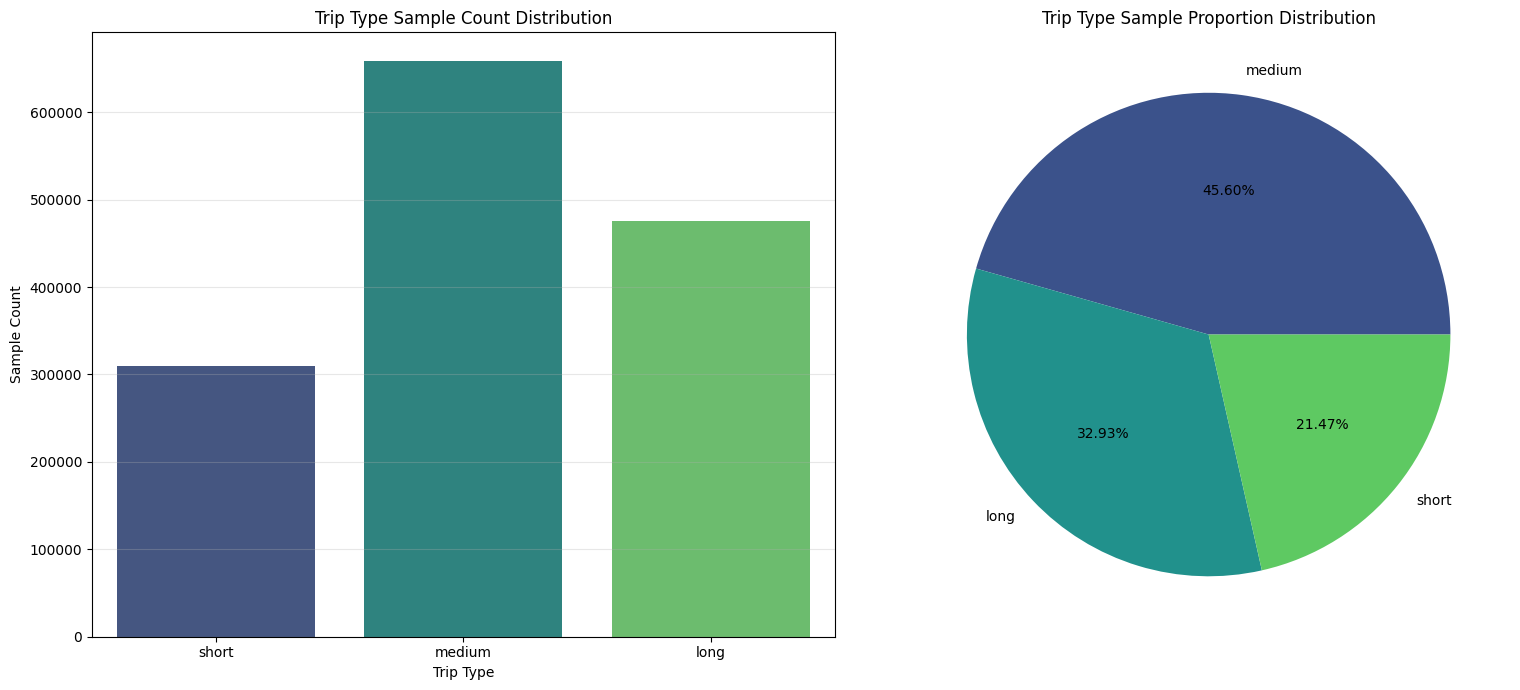

C:\Users\asahi\AppData\Local\Temp\ipykernel_44016\3381918279.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trip_type', y='distance', data=train_df, ax=axes[0], palette='viridis')
C:\Users\asahi\AppData\Local\Temp\ipykernel_44016\3381918279.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='trip_type', y='distance', data=train_df, ax=axes[1], palette='viridis')


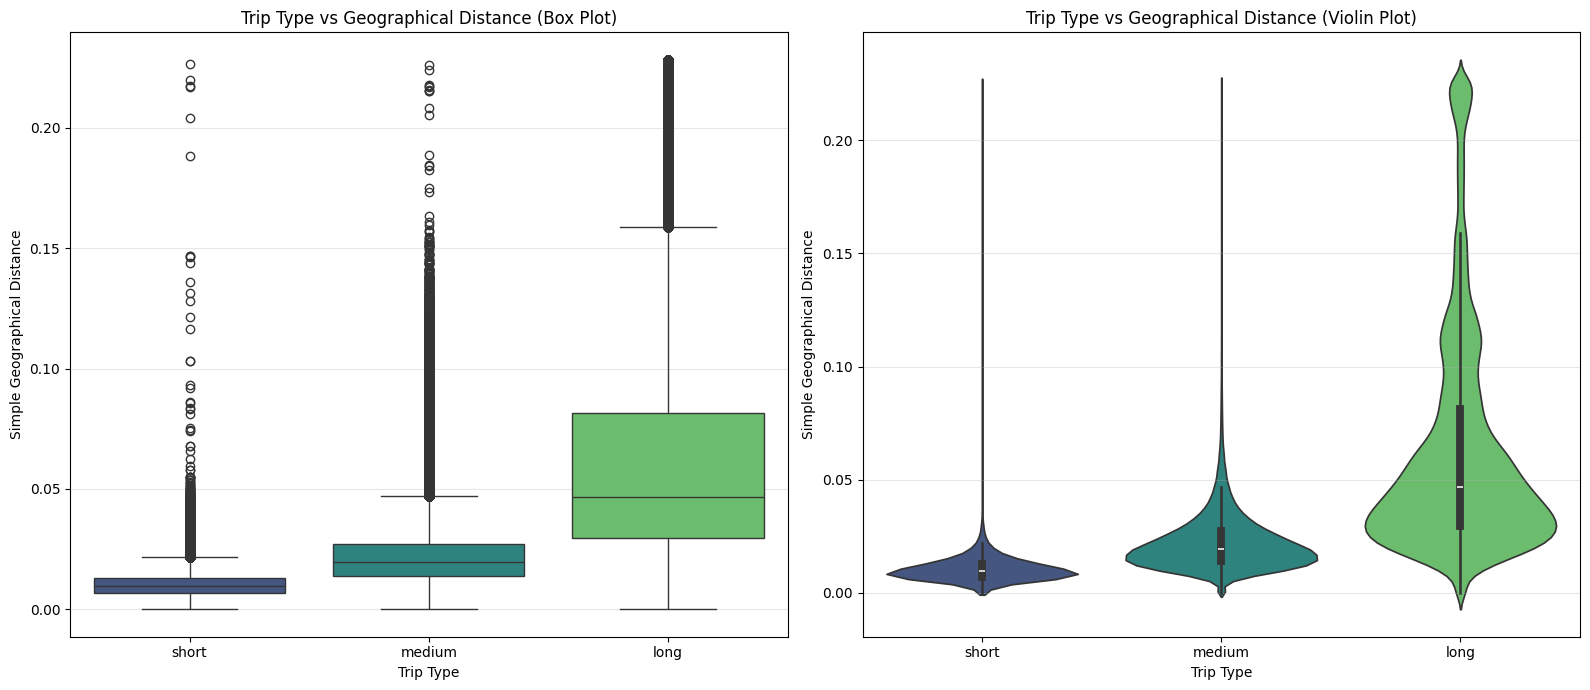

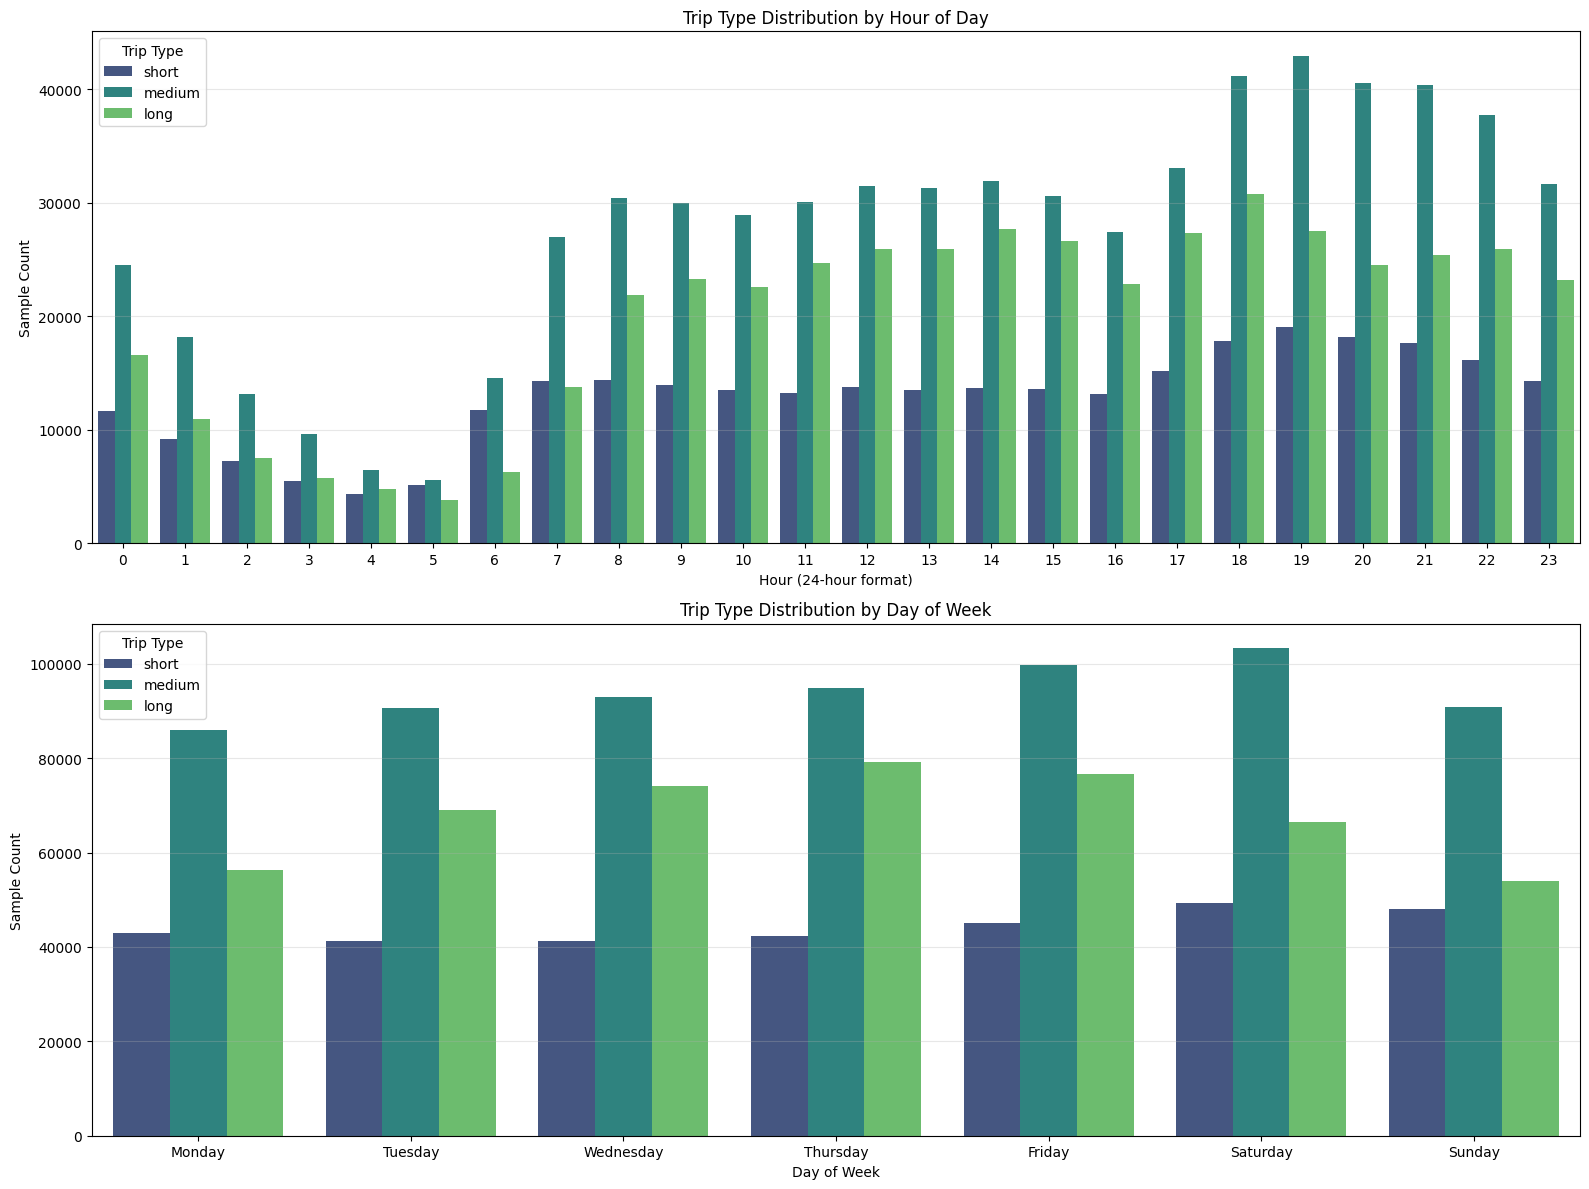

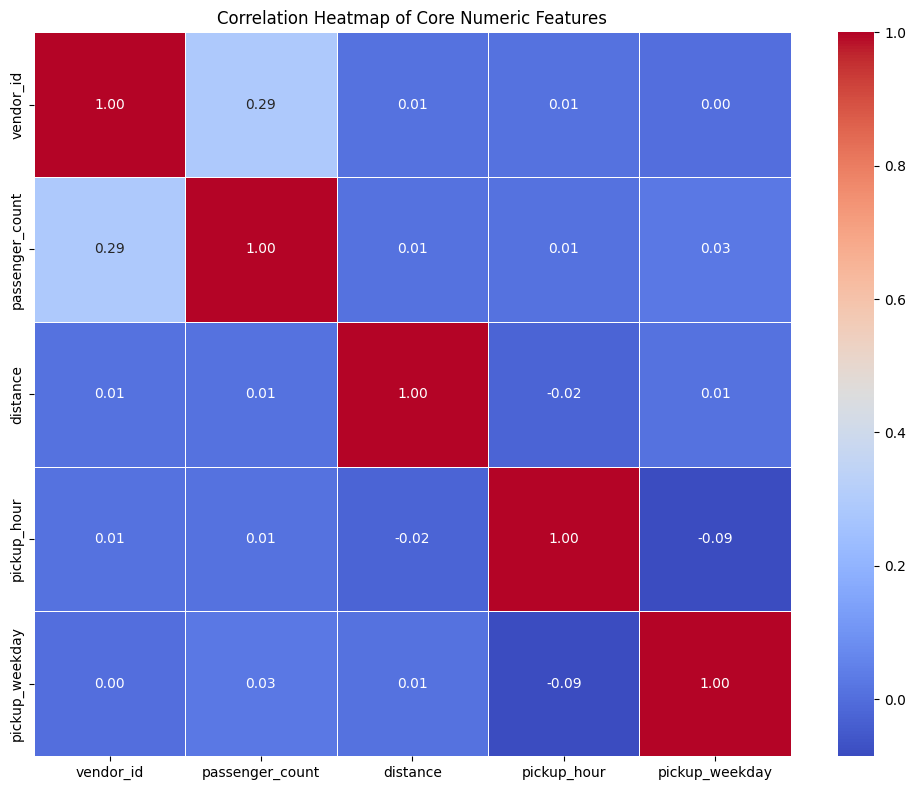

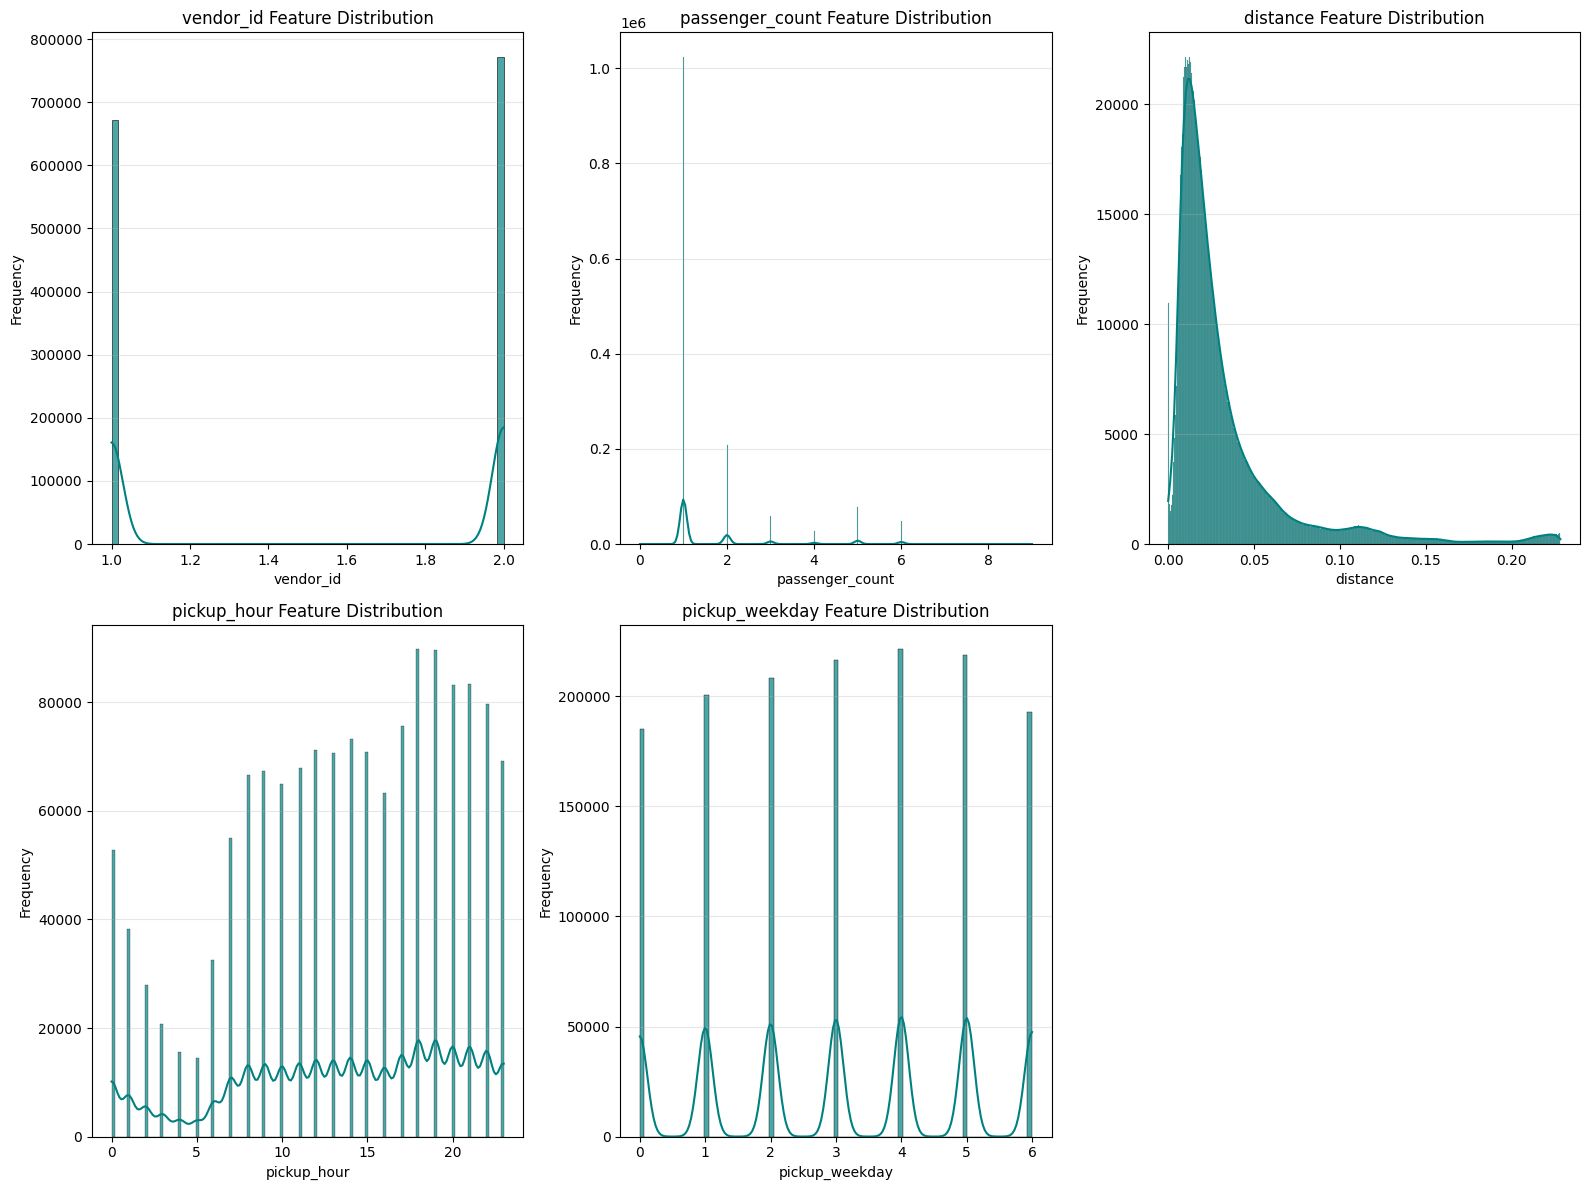

In [2]:


# Cell 2: Basic Data Visualization
# 1. Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
trip_count = train_df['trip_type'].value_counts()

# Count bar chart
sns.countplot(x='trip_type', data=train_df, palette='viridis', ax=axes[0])
axes[0].set_title('Trip Type Sample Count Distribution')
axes[0].set_xlabel('Trip Type')
axes[0].set_ylabel('Sample Count')
axes[0].grid(axis='y', alpha=0.3)

# Proportion pie chart
axes[1].pie(trip_count.values, labels=trip_count.index, autopct='%1.2f%%', colors=sns.color_palette('viridis', 3))
axes[1].set_title('Trip Type Sample Proportion Distribution')
plt.tight_layout()
plt.show()

# 2. Relationship between geographic distance and trip type (Box plot + Violin plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.boxplot(x='trip_type', y='distance', data=train_df, ax=axes[0], palette='viridis')
axes[0].set_title('Trip Type vs Geographical Distance (Box Plot)')
axes[0].set_xlabel('Trip Type')
axes[0].set_ylabel('Simple Geographical Distance')
axes[0].grid(axis='y', alpha=0.3)

sns.violinplot(x='trip_type', y='distance', data=train_df, ax=axes[1], palette='viridis')
axes[1].set_title('Trip Type vs Geographical Distance (Violin Plot)')
axes[1].set_xlabel('Trip Type')
axes[1].set_ylabel('Simple Geographical Distance')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Time feature distribution (Hour + Weekday)
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
# Hour distribution
sns.countplot(x='pickup_hour', hue='trip_type', data=train_df, ax=axes[0], palette='viridis')
axes[0].set_title('Trip Type Distribution by Hour of Day')
axes[0].set_xlabel('Hour (24-hour format)')
axes[0].set_ylabel('Sample Count')
axes[0].legend(title='Trip Type')
axes[0].grid(axis='y', alpha=0.3)

# Weekday distribution
train_df['weekday_name'] = train_df['pickup_weekday'].map({0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'})
sns.countplot(x='weekday_name', hue='trip_type', data=train_df, ax=axes[1], palette='viridis',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[1].set_title('Trip Type Distribution by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Sample Count')
axes[1].legend(title='Trip Type')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Correlation heatmap of core features
corr_cols = ['vendor_id', 'passenger_count', 'distance', 'pickup_hour', 'pickup_weekday']
corr_matrix = train_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Core Numeric Features')
plt.tight_layout()
plt.show()

# 5. Histogram of numeric feature distributions
plt.figure(figsize=(16, 12))
for idx, col in enumerate(corr_cols):
    plt.subplot(2, 3, idx+1)
    sns.histplot(train_df[col], kde=True, color='teal', alpha=0.7)
    plt.title(f'{col} Feature Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()






In [3]:




# Cell 3: Feature Preparation and Data Splitting
# Define feature columns
feature_cols = [
    'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_weekday',
    'pickup_month', 'distance', 'store_and_fwd_flag_Y'
]

# Training set split
X = train_df[feature_cols]
y = train_df['trip_type']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Test set features
X_test = test_df[feature_cols]




In [5]:



# Cell 4: Grid Search for Optimal Parameters
# Define models and parameter grids
param_grids = {
    'DT': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [6, 8, 10], 'min_samples_split': [10, 20], 'min_samples_leaf': [5, 10]}
    },
    'Gaussian': {
        'model': GaussianNB(),
        'params': {} 
    },
    'MLP': {  
        'model': MLPClassifier(random_state=42,  max_iter=500),  # early_stopping prevents overfitting, max_iter increases iterations
        'params': {
            'hidden_layer_sizes': [(32,), (64,)],  
            'activation': ['relu'], 
            'solver': ['adam'],  
            'alpha': [0.0001, 0.001]  
        }
    }
}

# Execute grid search
best_models = {}
print("=== Grid Search for Optimal Parameters ===")
for model_name, config in param_grids.items():
    print(f"\nSearching {model_name}...")
    if len(config['params']) > 0:
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=3,
            scoring='f1_weighted',
            n_jobs=8,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        
        # Store best results
        best_models[model_name] = {
            'best_model': grid_search.best_estimator_,
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_
        }
        
        # Print results
        print(f"{model_name} Best parameters: {grid_search.best_params_}")
        print(f"{model_name} Best CV F1: {grid_search.best_score_:.4f}")
    else:
        # GaussianNB direct training
        model = config['model']
        model.fit(X_train, y_train)
        from sklearn.model_selection import cross_val_score
        cv_score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_weighted').mean()
        
        best_models[model_name] = {
            'best_model': model,
            'best_params': 'None (GaussianNB requires no tuning)',
            'best_score': cv_score
        }
        print(f"{model_name} No tuning required, CV F1: {cv_score:.4f}")





=== Grid Search for Optimal Parameters ===

Searching DT...
DT Best parameters: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 10}
DT Best CV F1: 0.7457

Searching Gaussian...
Gaussian No tuning required, CV F1: 0.5736

Searching MLP...
MLP Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (32,), 'solver': 'adam'}
MLP Best CV F1: 0.7276


In [6]:





# Cell 5: Model Evaluation and Results Printing
# Evaluate best models
eval_metrics = []
for model_name, result in best_models.items():
    model = result['best_model']
    y_pred = model.predict(X_val)
    
    # Calculate core metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    # Store metrics
    eval_metrics.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Best_Params': str(result['best_params'])
    })
    
    # Print detailed report
    print(f"\n=== {model_name} Detailed Evaluation Results ===")
    print("1. Best parameters:", result['best_params'])
    print("2. Classification Report:")
    print(classification_report(y_val, y_pred, target_names=TRIP_LABELS))
    print("3. Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

eval_df = pd.DataFrame(eval_metrics)
print("\n=== All Models Evaluation Summary ===")
print(eval_df.round(4))







=== DT Detailed Evaluation Results ===
1. Best parameters: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 10}
2. Classification Report:
              precision    recall  f1-score   support

       short       0.82      0.75      0.79     95119
      medium       0.71      0.77      0.74    131694
        long       0.73      0.68      0.70     61999

    accuracy                           0.75    288812
   macro avg       0.75      0.74      0.74    288812
weighted avg       0.75      0.75      0.75    288812

3. Confusion Matrix:
[[ 71571  22464   1084]
 [ 15374 101677  14643]
 [   147  19644  42208]]

=== Gaussian Detailed Evaluation Results ===
1. Best parameters: None (GaussianNB requires no tuning)
2. Classification Report:
              precision    recall  f1-score   support

       short       0.86      0.46      0.60     95119
      medium       0.57      0.46      0.51    131694
        long       0.44      0.93      0.60     61999

    accuracy             

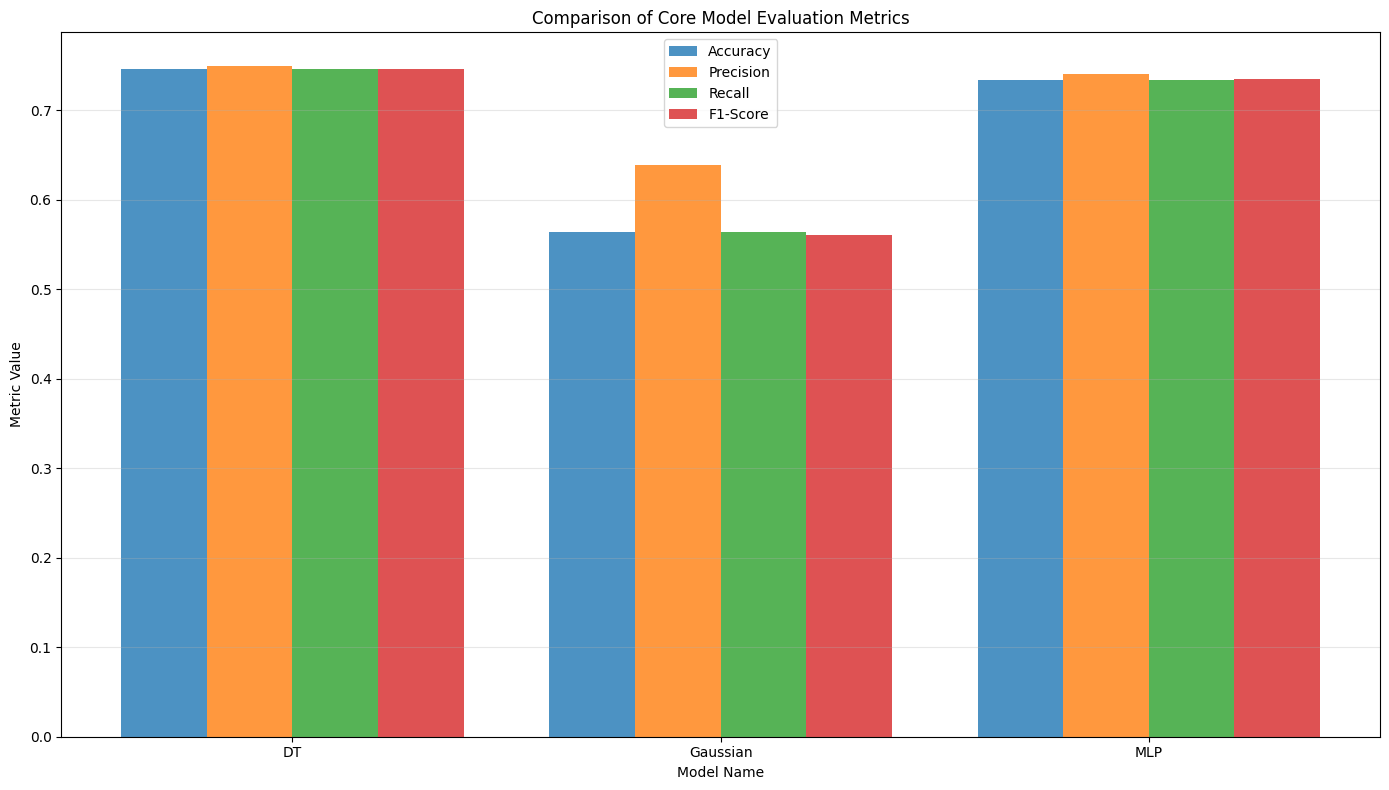

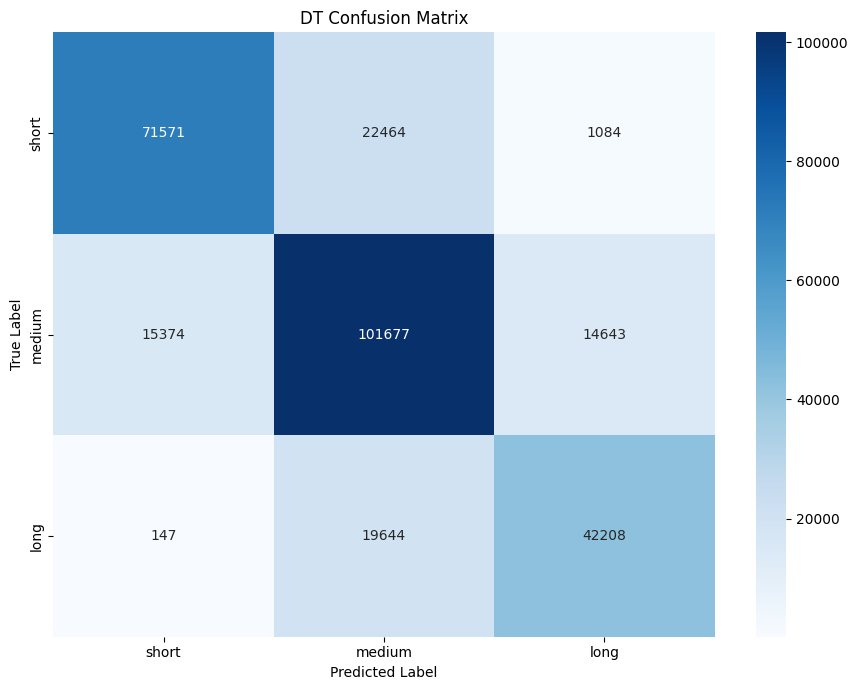

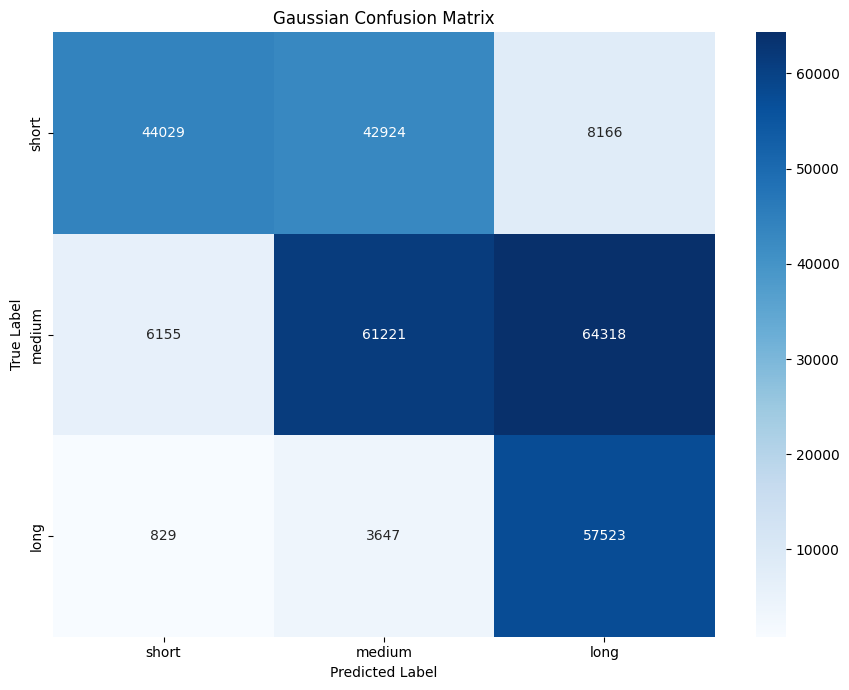

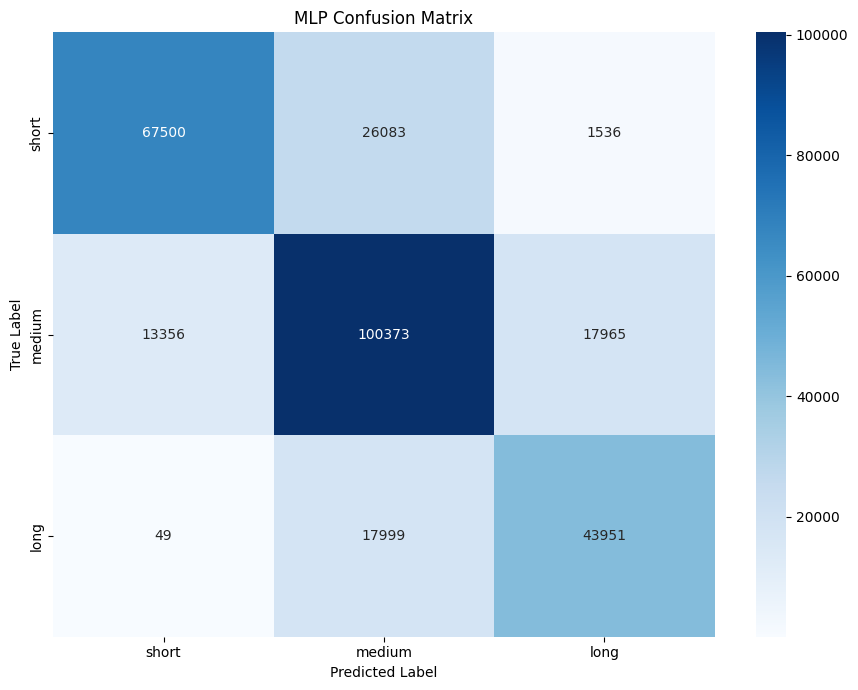

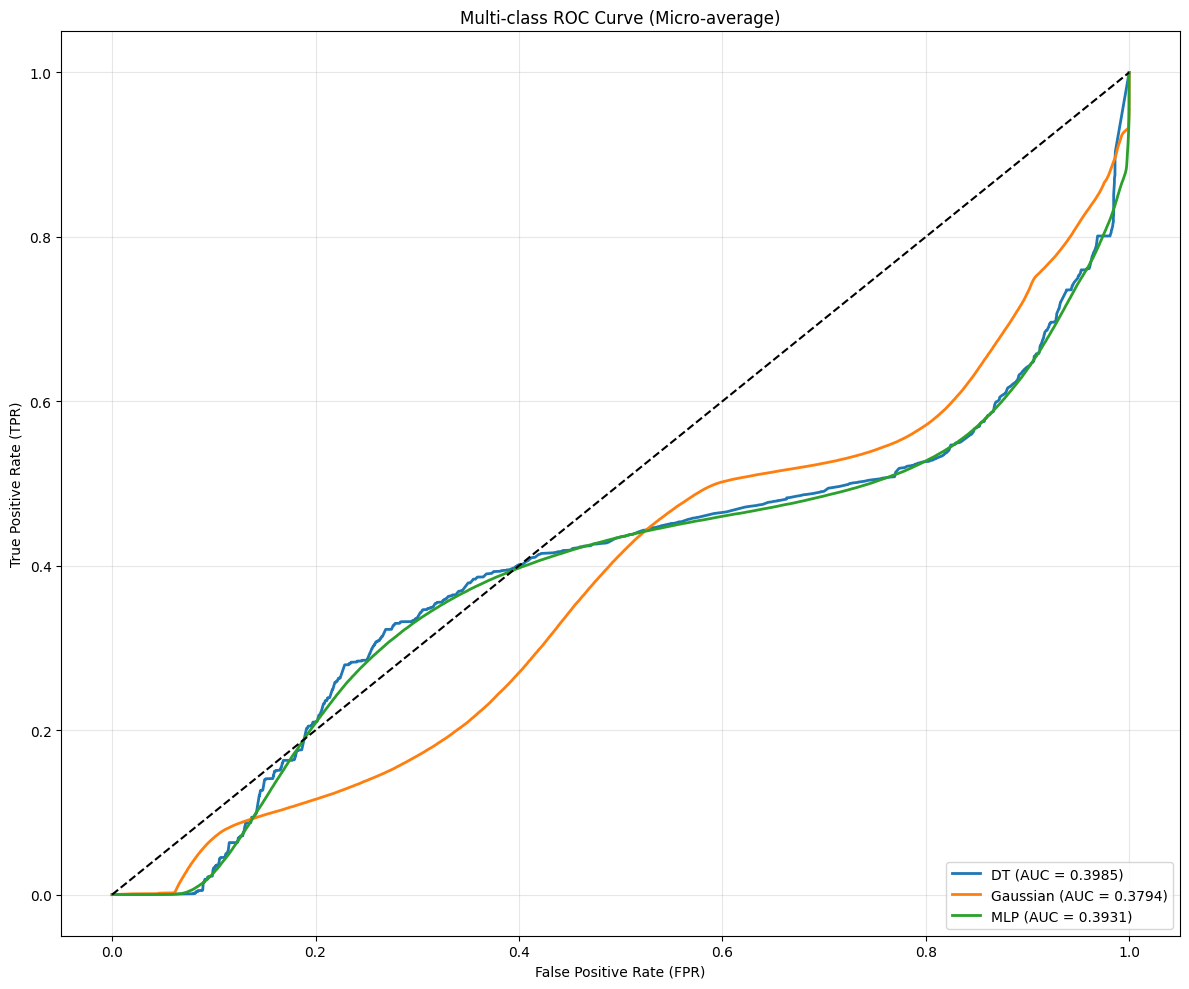

C:\Users\asahi\AppData\Local\Temp\ipykernel_44016\2007085738.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature Name', data=feat_imp_df, palette='viridis')


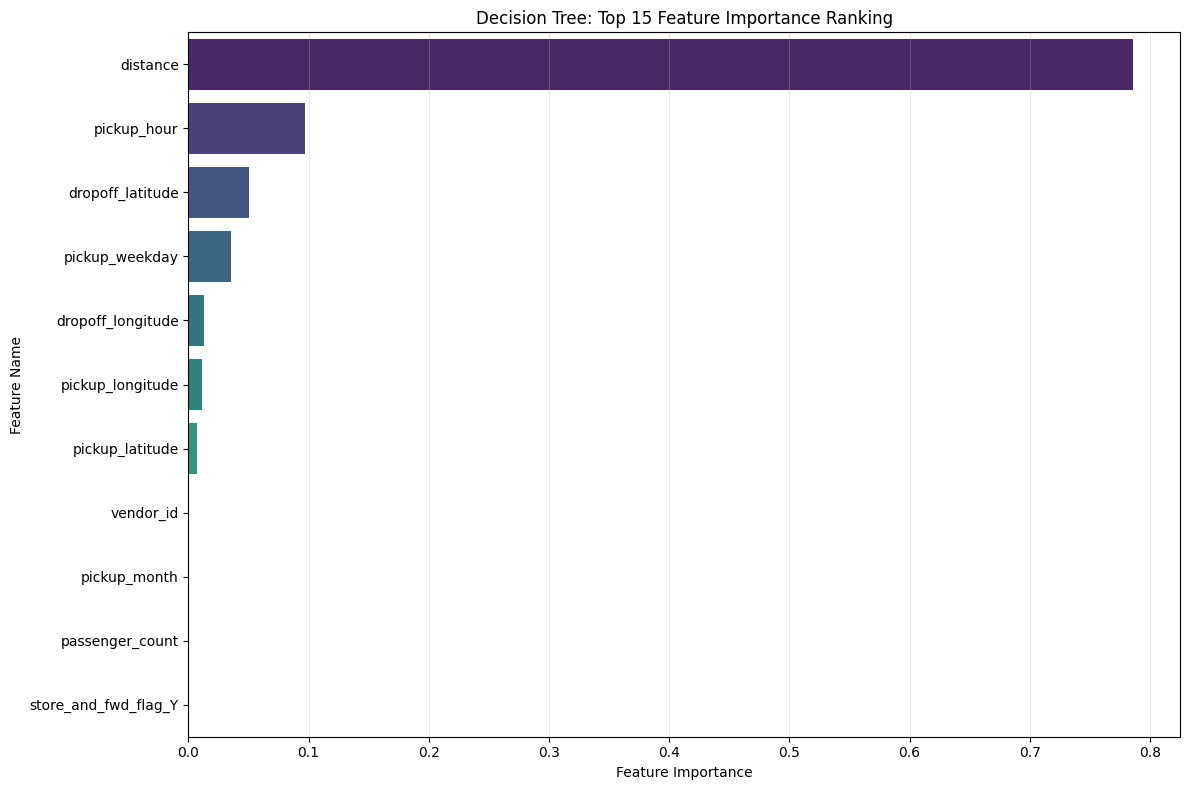

=== Decision Tree Feature Importance Details ===
            Feature Name  Importance
9               distance      0.7857
6            pickup_hour      0.0967
5       dropoff_latitude      0.0501
7         pickup_weekday      0.0356
4      dropoff_longitude      0.0128
2       pickup_longitude      0.0113
3        pickup_latitude      0.0069
0              vendor_id      0.0007
8           pickup_month      0.0002
1        passenger_count      0.0001
10  store_and_fwd_flag_Y      0.0000


In [7]:




# Cell 6: Evaluation Results Visualization

plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']  
x = np.arange(len(eval_df['Model']))
width = 0.2

for idx, metric in enumerate(metrics):
    plt.bar(x + idx*width, eval_df[metric], width=width, label=metric, alpha=0.8)

plt.xlabel('Model Name')
plt.ylabel('Metric Value')
plt.title('Comparison of Core Model Evaluation Metrics')
plt.xticks(x + width*1.5, eval_df['Model'])  
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix visualization
for model_name, result in best_models.items():
    model = result['best_model']
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TRIP_LABELS, yticklabels=TRIP_LABELS)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Multi-class ROC curve
y_val_bin = label_binarize(y_val, classes=TRIP_LABELS)
plt.figure(figsize=(12, 10))

for model_name, result in best_models.items():
    model = result['best_model']
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_val)
        fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multi-class ROC Curve (Micro-average)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Decision tree feature importance
dt_model = best_models['DT']['best_model']
importances = dt_model.feature_importances_
feat_imp_df = pd.DataFrame({
        'Feature Name': feature_cols,  
        'Importance': importances       
    }).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature Name', data=feat_imp_df, palette='viridis')
plt.title('Decision Tree: Top 15 Feature Importance Ranking')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Decision Tree Feature Importance Details ===")
print(feat_imp_df.round(4))



